In [21]:
import os, time, urllib.request, gc
import numpy as np, pandas as pd, psutil
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from google.colab import drive
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")

DIR_KERJA  = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA,  exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

URL_JAN = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_JUL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH  = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
PATH2 = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

proses  = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    dt = time.perf_counter() - t0
    dr = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(dt, 2),
                    "delta_rss_mb": round(dr, 1)})
    print(f"[{label}] {dt:.2f} s | RSS {dr:+.1f} MB")
    return hasil

def unduh(url, path):
    if not os.path.exists(path):
        ukur(f"unduh {os.path.basename(path)}",
             lambda: urllib.request.urlretrieve(url, path))
    return path

def j4_metadata(path, label):
    """J-4: metadata tanpa memuat baris."""
    m = pq.ParquetFile(path).metadata
    print(f"[{label}] ukuran={os.path.getsize(path)/1024**2:.1f} MB "
          f"baris={m.num_rows:,} kolom={m.num_columns} rowgroup={m.num_row_groups}")
    return m

def j5_baca_optimasi(path, label):
    """J-5: baca semua vs terpilih; optimasi tipe."""
    penuh = ukur(f"[{label}] baca semua kolom",
                 lambda: pd.read_parquet(path))
    print(f"[{label}] semua kolom: {penuh.shape} "
          f"| {penuh.memory_usage(deep=True).sum()/1024**2:.1f} MB")
    del penuh; gc.collect()

    df = ukur(f"[{label}] baca kolom terpilih",
              lambda: pd.read_parquet(path, columns=KOLOM))

    sebelum = df.memory_usage(deep=True).sum()/1024**2
    df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
    df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
    for k in ["trip_distance","fare_amount","tip_amount","total_amount"]:
        df[k] = pd.to_numeric(df[k], downcast="float")
    sesudah = df.memory_usage(deep=True).sum()/1024**2
    print(f"[{label}] memori {sebelum:.1f} -> {sesudah:.1f} MB "
          f"(hemat {100*(1-sesudah/sebelum):.1f}%)")
    return df, sebelum, sesudah

def j6_bersihkan(df, label):
    """J-6: describe, null, anomali, filter."""
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"]
                           - df["tpep_pickup_datetime"])
                          .dt.total_seconds()/60)
    print(f"\n[{label}] describe:")
    print(df[["trip_distance","durasi_menit","total_amount"]].describe())
    print(f"[{label}] null per kolom:")
    print(df.isna().sum().to_string())

    anomali = {
        "jarak <= 0":         int((df["trip_distance"] <= 0).sum()),
        "durasi <= 0":        int((df["durasi_menit"] <= 0).sum()),
        "durasi > 180 menit": int((df["durasi_menit"] > 180).sum()),
        "total_amount <= 0":  int((df["total_amount"] <= 0).sum()),
    }
    for k, v in anomali.items():
        print(f"[{label}] {k:22s}: {v:,} ({100*v/len(df):.2f}%)")

    layak = ((df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
             df["durasi_menit"].between(1, 180) &
             (df["total_amount"] > 0))
    b = df.loc[layak].copy()
    print(f"[{label}] {len(df):,} -> {len(b):,} "
          f"(dibuang {len(df)-len(b):,})")
    b["jam"] = b["tpep_pickup_datetime"].dt.hour
    return b, anomali

def j9_agregasi(bersih, label):
    """J-9: agregasi per jam."""
    def _agg():
        return (bersih.groupby("jam")
                .agg(jumlah_perjalanan=("total_amount","size"),
                     rata_jarak=("trip_distance","mean"),
                     rata_durasi=("durasi_menit","mean"),
                     rata_tarif=("total_amount","mean"),
                     median_tarif=("total_amount","median"))
                .round(2).reset_index())
    return ukur(f"[{label}] agregasi pandas", _agg)

print("✅ PRELUDE siap.")

✅ PRELUDE siap.


In [22]:
# ============ Q-1 ============
unduh(URL_JAN, PATH); unduh(URL_JUL, PATH2)

# --- J-4 metadata kedua file ---
meta_jan = j4_metadata(PATH,  "2023-01")
meta_jul = j4_metadata(PATH2, "2023-07")

# --- J-5 baca + optimasi ---
df_jan, sebelum_jan, sesudah_jan = j5_baca_optimasi(PATH,  "2023-01")
df_jul, sebelum_jul, sesudah_jul = j5_baca_optimasi(PATH2, "2023-07")

# --- J-6 pembersihan ---
bersih_jan, anomali_jan = j6_bersihkan(df_jan, "2023-01")
bersih_jul, anomali_jul = j6_bersihkan(df_jul, "2023-07")

# --- J-9 agregasi per jam ---
agg_jan = j9_agregasi(bersih_jan, "2023-01")
agg_jul = j9_agregasi(bersih_jul, "2023-07")

# --- Simpan agregasi CSV + PARQUET (deliverable wajib) ---
agg_jan.to_csv(    f"{DIR_SIMPAN}/agregasi_per_jam_2023-01.csv",    index=False)
agg_jan.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_2023-01.parquet", index=False)
agg_jul.to_csv(    f"{DIR_SIMPAN}/agregasi_per_jam_2023-07.csv",    index=False)
agg_jul.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_2023-07.parquet", index=False)

print("\nContoh agregasi Juli:")
display(agg_jul.head())

[2023-01] ukuran=45.5 MB baris=3,066,766 kolom=19 rowgroup=1
[2023-07] ukuran=46.1 MB baris=2,907,108 kolom=19 rowgroup=1
[[2023-01] baca semua kolom] 2.90 s | RSS +436.4 MB
[2023-01] semua kolom: (3066766, 19) | 565.6 MB
[[2023-01] baca kolom terpilih] 1.09 s | RSS +164.8 MB
[2023-01] memori 187.2 -> 119.9 MB (hemat 35.9%)
[[2023-07] baca semua kolom] 1.79 s | RSS +422.2 MB
[2023-07] semua kolom: (2907108, 19) | 502.5 MB
[[2023-07] baca kolom terpilih] 0.36 s | RSS +157.4 MB
[2023-07] memori 177.4 -> 113.7 MB (hemat 35.9%)

[2023-01] describe:
       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03
[2023-01

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000


In [23]:
# ============ J-7 untuk bulan baru ============
CSV_JUL = os.path.join(DIR_KERJA, "trips_jul.csv")
ukur("tulis CSV Juli", lambda: bersih_jul.to_csv(CSV_JUL, index=False))
print("Parquet Juli:", round(os.path.getsize(PATH2)/1024**2, 1), "MB")
print("CSV Juli    :", round(os.path.getsize(CSV_JUL)/1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah = 0; total = 0.0; per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime","total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah += len(chunk)
        total  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, v = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), v + sub["total_amount"].sum())
    return jumlah, total, per_jam

baris, total, _ = ukur("agregasi chunking Juli",
                       lambda: agregasi_bertahap(CSV_JUL))
print(f"Juli: {baris:,} baris | rata total_amount = {total/baris:.2f}")

[tulis CSV Juli] 37.34 s | RSS +0.0 MB
Parquet Juli: 46.1 MB
CSV Juli    : 221.1 MB
[agregasi chunking Juli] 8.10 s | RSS +7.0 MB
Juli: 2,817,657 baris | rata total_amount = 29.04


In [26]:
import os, time, urllib.request, gc
import numpy as np, pandas as pd, psutil
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from google.colab import drive
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")

DIR_KERJA  = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA,  exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

URL_JAN = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_JUL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH  = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
PATH2 = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

proses  = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    dt = time.perf_counter() - t0
    dr = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(dt, 2),
                    "delta_rss_mb": round(dr, 1)})
    print(f"[{label}] {dt:.2f} s | RSS {dr:+.1f} MB")
    return hasil

def unduh(url, path):
    if not os.path.exists(path):
        ukur(f"unduh {os.path.basename(path)}",
             lambda: urllib.request.urlretrieve(url, path))
    return path

def j4_metadata(path, label):
    """J-4: metadata tanpa memuat baris."""
    m = pq.ParquetFile(path).metadata
    print(f"[{label}] ukuran={os.path.getsize(path)/1024**2:.1f} MB "
          f"baris={m.num_rows:,} kolom={m.num_columns} rowgroup={m.num_row_groups}")
    return m

def j5_baca_optimasi(path, label):
    """J-5: baca semua vs terpilih; optimasi tipe."""
    penuh = ukur(f"[{label}] baca semua kolom",
                 lambda: pd.read_parquet(path))
    print(f"[{label}] semua kolom: {penuh.shape} "
          f"| {penuh.memory_usage(deep=True).sum()/1024**2:.1f} MB")
    del penuh; gc.collect()

    df = ukur(f"[{label}] baca kolom terpilih",
              lambda: pd.read_parquet(path, columns=KOLOM))

    sebelum = df.memory_usage(deep=True).sum()/1024**2
    df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
    df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
    for k in ["trip_distance","fare_amount","tip_amount","total_amount"]:
        df[k] = pd.to_numeric(df[k], downcast="float")
    sesudah = df.memory_usage(deep=True).sum()/1024**2
    print(f"[{label}] memori {sebelum:.1f} -> {sesudah:.1f} MB "
          f"(hemat {100*(1-sesudah/sebelum):.1f}%)")
    return df, sebelum, sesudah

def j6_bersihkan(df, label):
    """J-6: describe, null, anomali, filter."""
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"]
                           - df["tpep_pickup_datetime"])
                          .dt.total_seconds()/60)
    print(f"\n[{label}] describe:")
    print(df[["trip_distance","durasi_menit","total_amount"]].describe())
    print(f"[{label}] null per kolom:")
    print(df.isna().sum().to_string())

    anomali = {
        "jarak <= 0":         int((df["trip_distance"] <= 0).sum()),
        "durasi <= 0":        int((df["durasi_menit"] <= 0).sum()),
        "durasi > 180 menit": int((df["durasi_menit"] > 180).sum()),
        "total_amount <= 0":  int((df["total_amount"] <= 0).sum()),
    }
    for k, v in anomali.items():
        print(f"[{label}] {k:22s}: {v:,} ({100*v/len(df):.2f}%) Kishan)")

    layak = ((df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
             df["durasi_menit"].between(1, 180) &
             (df["total_amount"] > 0))
    b = df.loc[layak].copy()
    print(f"[{label}] {len(df):,} -> {len(b):,} "
          f"(dibuang {len(df)-len(b):,})")
    b["jam"] = b["tpep_pickup_datetime"].dt.hour
    return b, anomali

def j9_agregasi(bersih, label):
    """J-9: agregasi per jam."""
    def _agg():
        return (bersih.groupby("jam")
                .agg(jumlah_perjalanan=("total_amount","size"),
                     rata_jarak=("trip_distance","mean"),
                     rata_durasi=("durasi_menit","mean"),
                     rata_tarif=("total_amount","mean"),
                     median_tarif=("total_amount","median"))
                .round(2).reset_index())
    return ukur(f"[{label}] agregasi pandas", _agg)

print("✅ PRELUDE siap.")




# ============ J-8 untuk bulan baru ============
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01-Q")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH2)
sdf.printSchema()
print("Jumlah baris Juli:", ukur("spark count Juli", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime")))/60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi Juli", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

✅ PRELUDE siap.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spark: 3.5.1
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nulla

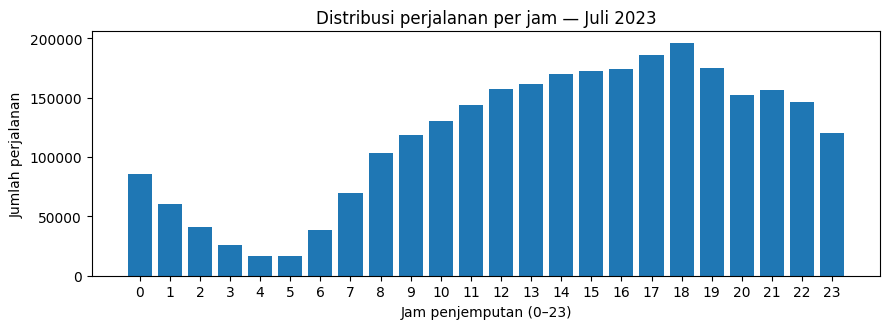

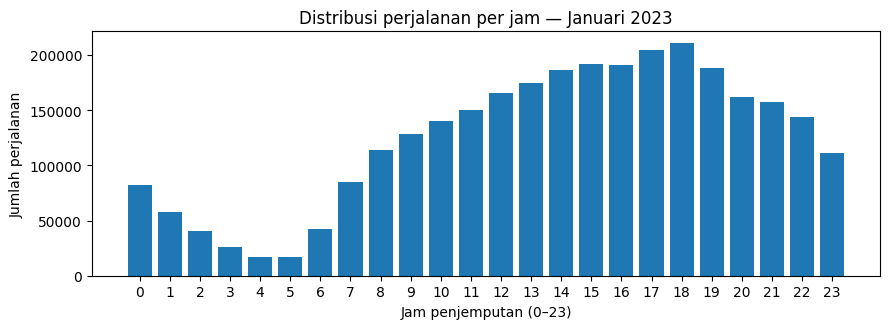

In [27]:
# ============ J-10 untuk bulan baru ============
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agg_jul["jam"], agg_jul["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam — Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_2023-07.png", dpi=150)
plt.show()

# bar chart Januari juga disimpan untuk kelengkapan
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agg_jan["jam"], agg_jan["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam — Januari 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_2023-01.png", dpi=150)
plt.show()

In [28]:
banding = (agg_jan[["jam","jumlah_perjalanan"]]
           .rename(columns={"jumlah_perjalanan":"jan_2023"})
           .merge(agg_jul[["jam","jumlah_perjalanan"]]
                  .rename(columns={"jumlah_perjalanan":"jul_2023"}),
                  on="jam", how="outer")
           .sort_values("jam").reset_index(drop=True))

banding["jan_pct"] = (100*banding["jan_2023"]/banding["jan_2023"].sum()).round(2)
banding["jul_pct"] = (100*banding["jul_2023"]/banding["jul_2023"].sum()).round(2)
banding["selisih_pct"] = (banding["jul_pct"] - banding["jan_pct"]).round(2)
banding.to_csv(f"{DIR_SIMPAN}/perbandingan_dua_bulan.csv", index=False)
banding

,jam,jan_2023,jul_2023,jan_pct,jul_pct,selisih_pct
0,0,82289,85987,2.75,3.05,0.30
1,1,57766,59980,1.93,2.13,0.20
2,2,40445,40812,1.35,1.45,0.10
3,3,26146,26000,0.88,0.92,0.04
4,4,16618,16637,0.56,0.59,0.03
5,5,16940,16913,0.57,0.60,0.03
6,6,42300,38422,1.42,1.36,-0.06
7,7,84569,69358,2.83,2.46,-0.37
8,8,114064,103647,3.82,3.68,-0.14
9,9,127988,118788,4.28,4.22,-0.06


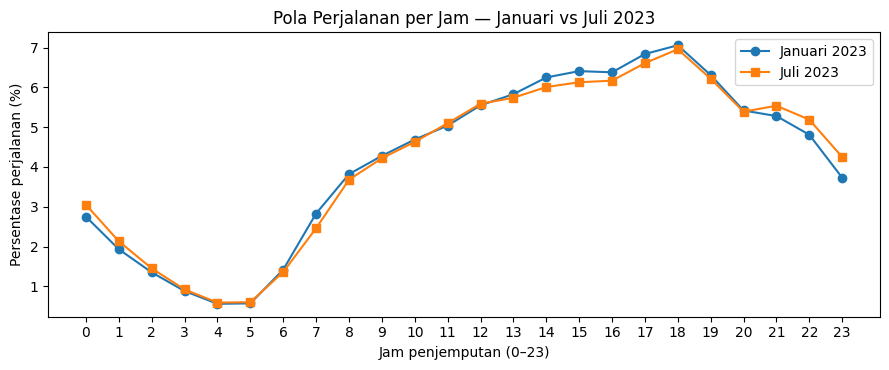

Jam puncak Januari: 18
Jam puncak Juli   : 18


In [29]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(banding["jam"], banding["jan_pct"], marker="o", label="Januari 2023")
ax.plot(banding["jam"], banding["jul_pct"], marker="s", label="Juli 2023")
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Persentase perjalanan (%)")
ax.set_title("Pola Perjalanan per Jam — Januari vs Juli 2023")
ax.set_xticks(range(0, 24)); ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_dua_bulan.png", dpi=150)
plt.show()

print("Jam puncak Januari:", int(banding.loc[banding.jan_pct.idxmax(),"jam"]))
print("Jam puncak Juli   :", int(banding.loc[banding.jul_pct.idxmax(),"jam"]))

In [30]:
k = pd.DataFrame(catatan)
k.to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

print("=== 5 langkah paling lama ===")
print(k.sort_values("detik", ascending=False).head(5).to_string(index=False))
print("\n=== 5 langkah paling boros memori ===")
print(k.sort_values("delta_rss_mb", ascending=False).head(5).to_string(index=False))

=== 5 langkah paling lama ===
            langkah  detik  delta_rss_mb
spark agregasi Juli   3.73           0.0
   spark count Juli   0.58           0.0

=== 5 langkah paling boros memori ===
            langkah  detik  delta_rss_mb
   spark count Juli   0.58           0.0
spark agregasi Juli   3.73           0.0


In [31]:
ringkas_5v = []
for lbl, d, b, p in [("2023-01", df_jan, bersih_jan, PATH),
                     ("2023-07", df_jul, bersih_jul, PATH2)]:
    total = len(d); bersih_ = len(b); anom = total - bersih_
    ringkas_5v.append({
        "bulan": lbl,
        "total_baris": total,
        "bersih": bersih_,
        "anomali": anom,
        "pct_anomali": round(100*anom/total, 2),
        "parquet_MB": round(os.path.getsize(p)/1024**2, 1),
    })

tabel_5v = pd.DataFrame(ringkas_5v)
tabel_5v.to_csv(f"{DIR_SIMPAN}/ringkasan_5v.csv", index=False)
tabel_5v

,bulan,total_baris,bersih,anomali,pct_anomali,parquet_MB
0,2023-01,3066766,2986911,79855,2.60,45.5
1,2023-07,2907108,2817657,89451,3.08,46.1


In [32]:
artefak = [
    "agregasi_per_jam_2023-01.csv",
    "agregasi_per_jam_2023-01.parquet",
    "agregasi_per_jam_2023-07.csv",
    "agregasi_per_jam_2023-07.parquet",
    "perbandingan_dua_bulan.csv",
    "perbandingan_dua_bulan.png",
    "distribusi_per_jam_2023-01.png",
    "distribusi_per_jam_2023-07.png",
    "pengukuran_kinerja.csv",
    "ringkasan_5v.csv",
]
print("Folder:", DIR_SIMPAN)
for f in artefak:
    p = os.path.join(DIR_SIMPAN, f)
    if os.path.exists(p):
        print(f"✅ {f:38s} {os.path.getsize(p)/1024:.1f} KB")
    else:
        print(f"❌ {f:38s} MISSING")

Folder: /content/drive/MyDrive/BigData/Praktikum1
✅ agregasi_per_jam_2023-01.csv           0.8 KB
✅ agregasi_per_jam_2023-01.parquet       4.7 KB
✅ agregasi_per_jam_2023-07.csv           0.8 KB
✅ agregasi_per_jam_2023-07.parquet       4.7 KB
✅ perbandingan_dua_bulan.csv             0.8 KB
✅ perbandingan_dua_bulan.png             70.4 KB
✅ distribusi_per_jam_2023-01.png         36.7 KB
✅ distribusi_per_jam_2023-07.png         36.6 KB
✅ pengukuran_kinerja.csv                 0.1 KB
✅ ringkasan_5v.csv                       0.1 KB
